# **Clase 12 - 🎯 Repaso integrador de cara al Primer Parcial**

### Laboratorio de Métodos Cuantitativos aplicados a la Gestión
**Tecnicatura Universitaria en Gestión y Análisis de Datos — FCE UBA**
Viernes 25 de septiembre de 2026 · Clase virtual · Unidades 1, 2 y 3

## ¿Qué vamos a hacer en esta clase?

Esta clase **no trae temas nuevos**. Todo lo que está acá ya lo vimos entre la clase 00 y la 11.

Lo que hacemos hoy es otra cosa: **ordenar** lo que ya saben, ponerlo en cuadros que se puedan
mirar de un saque, y practicar la parte que el parcial realmente evalúa, que es
**interpretar resultados**, no escribir código.

La idea es que al terminar la clase tengan esta notebook como material de estudio para los días
que quedan hasta el martes.

## Objetivos de la clase

Al terminar, deberían poder:

1. **Leer** un array, un `DataFrame`, una derivada y una salida de optimización, y decir qué dicen
   sobre la organización del caso.
2. **Distinguir** las herramientas que se parecen y se confunden: `*` contra `@`, `.loc` contra
   `.iloc`, `linprog` contra `PuLP`.
3. **Resolver a mano** el circuito completo de optimización: derivar, igualar a cero, verificar con
   la segunda derivada e interpretar el resultado en pesos y unidades.
4. **Detectar errores** en un bloque de código o en un filtro: qué hace, qué devuelve y dónde está
   la falla.

## 🗺️ Qué entra en el parcial (y cómo se corrige)

El parcial es el **martes 29 de septiembre a las 17:00**, dura 3 horas, es **en papel** y
**no se usa computadora**. Entran las **Unidades 1, 2 y 3**.

| Bloque de la materia | Clases | Qué se pide en el parcial |
|---|---|---|
| Python, datos y archivos | 00, 01 | Leer un bloque de código y decir qué devuelve |
| Visualización | 02 | **Interpretar** un gráfico ya hecho |
| Funciones económicas y equilibrio | 03, 04 | Plantear costo, ingreso, beneficio; leer un equilibrio |
| Vectores y matrices | 05 | Operar e interpretar `axis`, `*` contra `@` |
| Filtrado y muestreo | 06 | Decir si un filtro está bien hecho y qué deja afuera |
| Sistemas de ecuaciones | 07 | Plantear el sistema e interpretar la solución |
| Programación lineal | 08 | Plantear el modelo y **leer la salida** |
| Derivadas y variaciones | 09 | Derivar, interpretar el signo |
| Marginales y elasticidades | 10 | Costo, ingreso y beneficio marginal; elasticidad |
| Optimización | 11 | Máximos y mínimos con criterio de segunda derivada |



## 📖 Cómo usar esta notebook

- **Durante la clase:** seguimos los bloques en orden. Cada bloque tiene una parte de teoría
  condensada (los cuadros) y un ejemplo corto que corremos juntos.
- **Después de la clase:** los cuadros funcionan como machete conceptual para repasar, y al final
  hay **ejercicios tipo parcial** con la resolución escondida (hacelos antes de abrirla).
- **Ojo:** el machete es para estudiar **ahora**, no para el examen. El martes no se puede llevar
  ningún material.

Arranquemos importando lo que vamos a usar en toda la clase.

In [ ]:
# Paso 1: importamos las librerías de siempre
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# PuLP no viene preinstalado en todos los entornos.
# Si esta celda falla en Colab, descomentá la línea del pip install y volvé a correrla.
# !pip install pulp -q
try:
    import pulp
    PULP_OK = True
except ImportError:
    PULP_OK = False
    print("PuLP no está instalado: la celda de PuLP se va a saltear.")

print("Librerías listas. NumPy", np.__version__, "| pandas", pd.__version__)

Librerías listas. NumPy 2.0.2 | pandas 2.3.2


---
# 🔢 Bloque 1 — NumPy: arrays y vectores

## La teoría en cuatro líneas

Un **array** de NumPy es una fila (o una tabla) de números **todos del mismo tipo**. Eso es lo que
lo hace rápido y lo que lo diferencia de una lista de Python.

| Concepto | Qué significa | Cómo se ve |
|---|---|---|
| **Vector** | Un array de una dimensión: una lista de números | `np.array([10, 20, 30])` |
| **Matriz** | Un array de dos dimensiones: filas y columnas | `np.array([[1, 2], [3, 4]])` |
| **`dtype`** | El tipo de dato del array; es **uno solo** para todo el array | `int64`, `float64` |
| **`shape`** | La forma: `(filas, columnas)` | `(3,)` es un vector de 3; `(2, 2)` una matriz 2×2 |
| **Vectorización** | Operar sobre todo el array de una, sin `for` | `ventas * 1.21` |

La **vectorización** es la razón de ser de NumPy: en lugar de recorrer con un `for`, se le pide la
operación al array completo y NumPy la aplica elemento por elemento.

In [ ]:
# Un vector: las ventas de tres sucursales, en miles de pesos
ventas = np.array([120, 340, 275])

print("El vector:      ", ventas)
print("Su forma:       ", ventas.shape, "-> un vector de 3 elementos")
print("Su tipo de dato:", ventas.dtype)

# Vectorización: le sumamos el IVA a TODAS las sucursales de una sola vez, sin for
ventas_con_iva = ventas * 1.21
print("\nCon IVA:        ", ventas_con_iva.round(2))

# Sumar dos vectores: se suma posición por posición (elemento a elemento)
costos = np.array([80, 200, 190])
print("Margen bruto:   ", ventas - costos)

El vector:       [120 340 275]
Su forma:        (3,) -> un vector de 3 elementos
Su tipo de dato: int64

Con IVA:         [145.2  411.4  332.75]
Margen bruto:    [ 40 140  85]


## ✖️ `*` contra `@`: la confusión más común del bloque

Son **dos multiplicaciones distintas** y dan resultados distintos:

| Operador | Cómo se llama | Qué hace | Cuándo se usa |
|---|---|---|---|
| `*` | Producto **elemento a elemento** | Multiplica cada posición con la que está en la misma posición | Precios × cantidades de cada producto |
| `@` | Producto **matricial** (o escalar entre vectores) | Multiplica y **suma**: devuelve un total | Facturación total, insumo-producto |

La regla práctica: **si el resultado tiene que ser un total, va `@`; si tiene que seguir siendo una
lista de valores, va `*`.**

In [ ]:
precios    = np.array([100, 250, 80])   # precio de cada producto
cantidades = np.array([10,   4,  25])   # unidades vendidas de cada producto

# Con * : cuánto facturó CADA producto (sigue habiendo tres números)
por_producto = precios * cantidades
print("Facturación por producto:", por_producto)

# Con @ : cuánto facturó el negocio EN TOTAL (multiplica y suma: un solo número)
total = precios @ cantidades
print("Facturación total:       ", total)

# Es exactamente lo mismo que sumar el resultado de *
print("Comprobación:            ", por_producto.sum())

Facturación por producto: [1000 1000 2000]
Facturación total:        4000
Comprobación:             4000


## 🧭 `axis`: la pregunta que confunde a todo el mundo

Cuando la tabla tiene dos dimensiones hay que decirle a NumPy **en qué dirección** resumir:

| Qué escribo | En qué dirección se mueve | Qué pregunta responde | Qué devuelve |
|---|---|---|---|
| `M.sum()` | Todo | ¿Cuál es el total general? | **Un** número |
| `M.sum(axis=0)` | Hacia abajo, recorre **filas** | ¿Cuánto por **columna**? | Un valor por columna |
| `M.sum(axis=1)` | Hacia el costado, recorre **columnas** | ¿Cuánto por **fila**? | Un valor por fila |

> 💡 **Truco para no dudar:** `axis=0` es el eje de las filas, así que **las filas desaparecen** y
> queda un resultado por columna. `axis=1` es el eje de las columnas, así que **las columnas
> desaparecen** y queda un resultado por fila. El eje que nombrás es el que se consume.

In [ ]:
# Filas = sucursales (Centro, Norte, Sur) | Columnas = trimestres (T1, T2, T3, T4)
M = np.array([[120, 135, 150, 160],
              [340, 310, 360, 380],
              [275, 290, 285, 300]])

print("Forma de la tabla:", M.shape, "-> 3 sucursales x 4 trimestres\n")
print("Total general:              ", M.sum())
print("Total por trimestre (axis=0):", M.sum(axis=0), "<- 4 valores, uno por columna")
print("Total por sucursal (axis=1): ", M.sum(axis=1), "<- 3 valores, uno por fila")

# Y el promedio por sucursal, con el mismo criterio
print("\nPromedio por sucursal:      ", M.mean(axis=1).round(1))

Forma de la tabla: (3, 4) -> 3 sucursales x 4 trimestres

Total general:               3105
Total por trimestre (axis=0): [735 735 795 840] <- 4 valores, uno por columna
Total por sucursal (axis=1):  [ 565 1390 1150] <- 3 valores, uno por fila

Promedio por sucursal:       [141.2 347.5 287.5]


> ⚠️ **Errores clásicos de este bloque (los que se ven en el parcial)**
>
> | Error | Qué pasa | Cómo se detecta |
> |---|---|---|
> | Usar `*` donde iba `@` | Devuelve una lista en lugar de un total | El resultado tiene más de un número cuando se pedía uno solo |
> | Confundir `axis=0` con `axis=1` | El resultado tiene la cantidad de valores equivocada | Contá: ¿hay un valor por sucursal o por trimestre? |
> | Sumar arrays de distinto largo | Error de forma, o un resultado inesperado por *broadcasting* | Mirá siempre `.shape` antes de operar |
> | Suponer el `dtype` | Si el array es `int`, una división puede truncar | Revisá `.dtype` cuando el número no cierra |

---
# 🐼 Bloque 2 — pandas: indexar y filtrar

## Las dos piezas de pandas

| Pieza | Qué es | Analogía |
|---|---|---|
| **`Series`** | Una columna con su índice | Una columna de Excel |
| **`DataFrame`** | Una tabla: varias `Series` que comparten índice | Una hoja de Excel entera |

Y la trampa de notación que más cuesta:

| Cómo escribo | Qué me devuelve |
|---|---|
| `df["ventas"]` | Corchete **simple**: una `Series` (una columna sola) |
| `df[["ventas"]]` | Corchete **doble**: un `DataFrame` de una columna |
| `df[["ventas", "costos"]]` | Corchete doble: un `DataFrame` de dos columnas |

> 💡 **Por qué importa en el parcial:** si la consigna pide "una tabla" y el código devuelve una
> `Series`, eso es parte de la respuesta. El doble corchete es lo que mantiene la forma de tabla.

In [ ]:
# Armamos una tabla chica para trabajar en todo el bloque
datos = pd.DataFrame({
    "sucursal":  ["Centro", "Norte", "Sur", "Oeste", "Centro", "Norte"],
    "mes":       ["ene", "ene", "ene", "ene", "feb", "feb"],
    "ventas":    [120, 340, 275, 90, 135, 310],
    "empleados": [4, 9, 7, 3, 4, 9],
})

print("Forma:", datos.shape, "-> 6 filas, 4 columnas\n")
datos

Forma: (6, 4) -> 6 filas, 4 columnas



,sucursal,mes,ventas,empleados
0,Centro,ene,120,4
1,Norte,ene,340,9
2,Sur,ene,275,7
3,Oeste,ene,90,3
4,Centro,feb,135,4
5,Norte,feb,310,9


In [ ]:
# Corchete simple contra corchete doble: MISMA columna, distinta forma
una_serie = datos["ventas"]
una_tabla = datos[["ventas"]]

print("Con corchete simple ->", type(una_serie).__name__, "| forma:", una_serie.shape)
print("Con corchete doble  ->", type(una_tabla).__name__, "| forma:", una_tabla.shape)

Con corchete simple -> Series | forma: (6,)
Con corchete doble  -> DataFrame | forma: (6, 1)


## 🎯 `.loc` contra `.iloc`: la diferencia que hay que tener clarísima

| | `.loc` | `.iloc` |
|---|---|---|
| **Busca por** | **Etiqueta** (el nombre del índice o de la columna) | **Posición** (el número de orden, empezando en 0) |
| **Se lee** | "*location*": dónde está, por nombre | "*integer location*": dónde está, por número |
| **Ejemplo** | `datos.loc[0, "ventas"]` | `datos.iloc[0, 2]` |
| **El final del rango** | **Incluido**: `.loc[0:2]` trae 3 filas | **Excluido**: `.iloc[0:2]` trae 2 filas |
| **Acepta condiciones** | Sí: `datos.loc[datos["ventas"] > 200]` | No |

> ⚠️ **La trampa del rango** es el error que más cae: `.loc[0:2]` devuelve **tres** filas (la 0, la 1
> y la 2) porque incluye el final, mientras que `.iloc[0:2]` devuelve **dos** (la 0 y la 1), como
> cualquier rebanado de Python.

In [ ]:
# Mismo dato, dos caminos
print("Con .loc  (etiqueta 0, columna 'ventas'):", datos.loc[0, "ventas"])
print("Con .iloc (posición 0, posición 2):      ", datos.iloc[0, 2])

# La trampa del rango
print("\n.loc[0:2]  ->", len(datos.loc[0:2]), "filas (el final ESTÁ incluido)")
print(".iloc[0:2] ->", len(datos.iloc[0:2]), "filas (el final NO está incluido)")

Con .loc  (etiqueta 0, columna 'ventas'): 120
Con .iloc (posición 0, posición 2):       120

.loc[0:2]  -> 3 filas (el final ESTÁ incluido)
.iloc[0:2] -> 2 filas (el final NO está incluido)


## ↔️ ¿Está agarrando una fila o una columna?

Esta es una pregunta típica de parcial: te muestran un bloque y hay que decir qué devuelve.

| Cómo escribo | Qué agarra | Qué devuelve |
|---|---|---|
| `datos["ventas"]` | Una **columna** completa | `Series` de 6 valores |
| `datos.loc[2]` | Una **fila** completa | `Series` con los 4 campos de esa fila |
| `datos.loc[2, "ventas"]` | Una **celda** | Un solo valor |
| `datos.loc[:, "ventas"]` | Todas las filas de una columna | `Series` (los dos puntos significan "todas") |
| `datos.loc[2, :]` | Todas las columnas de una fila | `Series` |

> 💡 **Cómo darse cuenta:** en `.loc[fila, columna]` el **primer** lugar siempre es la fila y el
> **segundo** la columna. Si hay un solo argumento, es la fila.

In [ ]:
print("Una columna -> datos['ventas']:")
print(datos["ventas"].to_string(), "\n")

print("Una fila -> datos.loc[2]:")
print(datos.loc[2].to_string(), "\n")

print("Una celda -> datos.loc[2, 'ventas']:", datos.loc[2, "ventas"])

Una columna -> datos['ventas']:
0    120
1    340
2    275
3     90
4    135
5    310 

Una fila -> datos.loc[2]:
sucursal     Sur
mes          ene
ventas       275
empleados      7 

Una celda -> datos.loc[2, 'ventas']: 275


## ✂️ Filtrar: ¿está bien filtrado?

Filtrar es quedarse con las filas que cumplen una condición. Se hace con una **máscara booleana**:
una columna de `True` y `False` que dice, fila por fila, si entra o no.

El proceso tiene dos pasos, y conviene verlos separados:

1. **La condición** `datos["ventas"] > 200` devuelve la máscara.
2. **El filtro** `datos[datos["ventas"] > 200]` usa la máscara para quedarse con las filas `True`.

In [ ]:
# Paso 1: la máscara (qué filas cumplen)
mascara = datos["ventas"] > 200
print("La máscara:")
print(mascara.to_string(), "\n")

# Paso 2: el filtro (quedarse con esas filas)
grandes = datos[mascara]
print("Filas que quedaron:", len(grandes), "de", len(datos))
grandes

La máscara:
0    False
1     True
2     True
3    False
4    False
5     True 

Filas que quedaron: 3 de 6


,sucursal,mes,ventas,empleados
1,Norte,ene,340,9
2,Sur,ene,275,7
5,Norte,feb,310,9


### ⚠️ Los cuatro errores de filtrado que hay que saber reconocer

| Error | Cómo se escribe mal | Cómo se escribe bien | Qué pasa si está mal |
|---|---|---|---|
| **`and` en lugar de `&`** | `df[(a > 1) and (b < 2)]` | `df[(a > 1) & (b < 2)]` | Tira error: `and` no sabe trabajar con columnas enteras |
| **Faltan los paréntesis** | `df[a > 1 & b < 2]` | `df[(a > 1) & (b < 2)]` | El `&` se evalúa antes que el `>` y el resultado es otro |
| **`=` en lugar de `==`** | `df[df["mes"] = "ene"]` | `df[df["mes"] == "ene"]` | Error de sintaxis: uno asigna, el otro compara |
| **Filtrar y no mirar cuánto quedó** | — | `len(df_filtrado)` | Te quedás con 0 filas (o con todas) y no te enterás |

> 📌 **Lo que se pregunta en el parcial no es "escribí el filtro", es "¿este filtro está bien?".**
> Para responder eso hay que decir tres cosas: qué condición aplica, **cuántas filas deja** y
> **cuáles deja afuera**.

In [ ]:
# Filtro con DOS condiciones, bien escrito: & entre paréntesis
correcto = datos[(datos["ventas"] > 200) & (datos["mes"] == "ene")]
print("Filtro correcto -> quedan", len(correcto), "filas:")
print(correcto[["sucursal", "mes", "ventas"]].to_string(index=False))

# El mismo filtro con | (o): cambia por completo lo que queda
con_o = datos[(datos["ventas"] > 200) | (datos["mes"] == "ene")]
print("\nCon | en lugar de & -> quedan", len(con_o), "filas. No es lo mismo.")

Filtro correcto -> quedan 2 filas:
sucursal mes  ventas
   Norte ene     340
     Sur ene     275

Con | en lugar de & -> quedan 5 filas. No es lo mismo.


## 📊 `groupby`: resumir por categoría

`groupby` hace siempre lo mismo, en tres pasos: **parte** la tabla por una columna, **aplica** una
cuenta a cada grupo y **junta** los resultados.

Se lee así: `datos.groupby("sucursal")["ventas"].sum()` → *"agrupá por sucursal, mirá la columna
ventas y sumala"*.

In [ ]:
# Total vendido por sucursal
por_sucursal = datos.groupby("sucursal")["ventas"].sum()
print("Ventas por sucursal:")
print(por_sucursal.to_string(), "\n")

# Y un resumen con dos cuentas a la vez
resumen = datos.groupby("sucursal").agg(
    ventas_totales=("ventas", "sum"),
    meses_con_datos=("ventas", "count"),
    empleados=("empleados", "max"),
)
resumen

Ventas por sucursal:
sucursal
Centro    255
Norte     650
Oeste      90
Sur       275 



,ventas_totales,meses_con_datos,empleados
sucursal,,,
Centro,255,2,4
Norte,650,2,9
Oeste,90,1,3
Sur,275,1,7


> 💡 **Cómo se interpreta un `groupby` en el parcial:** el índice del resultado son las **categorías**
> y los valores son la **cuenta pedida**. Antes de interpretar, verificá que la suma de los grupos dé
> el total general: si no da, el filtro o el agrupamiento dejaron filas afuera.

---
# 💰 Bloque 3 — Funciones económicas y lectura de gráficos

## El cuadro de definiciones

Todo el bloque económico de la materia se apoya en estas funciones. Conviene tenerlas de memoria:

| Función | Notación | Fórmula | Qué significa |
|---|---|---|---|
| Costo fijo | $CF$ | constante | Lo que se paga aunque no se produzca nada |
| Costo variable | $CV(q)$ | depende de $q$ | Lo que cuesta producir, crece con la cantidad |
| **Costo total** | $CT(q)$ | $CF + CV(q)$ | Todo lo que cuesta producir $q$ |
| **Costo medio** | $CMe(q)$ | $\dfrac{CT(q)}{q}$ | Cuánto cuesta **cada** unidad en promedio |
| **Costo marginal** | $CMg(q)$ | $\dfrac{dCT}{dq}$ | Cuánto cuesta producir **una unidad más** |
| **Ingreso total** | $IT(q)$ | $p \cdot q$ | Lo que entra por vender $q$ unidades |
| **Ingreso marginal** | $IMg(q)$ | $\dfrac{dIT}{dq}$ | Cuánto entra por vender **una unidad más** |
| **Beneficio** | $B(q)$ | $IT(q) - CT(q)$ | Lo que queda |

> ⚠️ **Costo medio y costo marginal no son lo mismo**, y es un error clásico mezclarlos. El medio
> **divide** (reparte el total entre las unidades); el marginal **deriva** (mira el cambio por una
> unidad extra).

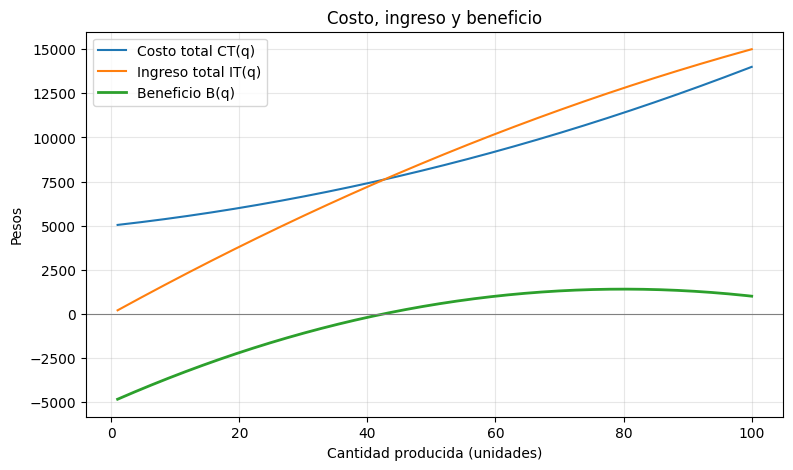

In [ ]:
# Una fábrica: costo fijo de $5.000 y un costo variable que crece más que proporcionalmente
q = np.linspace(1, 100, 300)      # cantidades posibles

CF = 5000
def costo_total(q):  return CF + 40 * q + 0.5 * q**2
def ingreso(q):      return 200 * q - 0.5 * q**2     # el precio baja cuando se vende más
def beneficio(q):    return ingreso(q) - costo_total(q)

# Graficamos las tres juntas
plt.figure(figsize=(9, 5))
plt.plot(q, costo_total(q), label="Costo total CT(q)")
plt.plot(q, ingreso(q),     label="Ingreso total IT(q)")
plt.plot(q, beneficio(q),   label="Beneficio B(q)", linewidth=2)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Costo, ingreso y beneficio")
plt.xlabel("Cantidad producida (unidades)")
plt.ylabel("Pesos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 🧠 Lo que hay que ver en ese gráfico

Un gráfico así aparece en el parcial y se pide interpretarlo. Lo que se mira, en este orden:

1. **Dónde arranca cada curva.** El costo total no arranca en cero: arranca en el **costo fijo**
   ($5.000). El ingreso sí arranca en cero, porque sin vender no entra nada.
2. **Dónde se cruzan $IT$ y $CT$.** Ahí el beneficio es cero: son los **puntos de nivelación**. A la
   izquierda del primero se pierde plata, en el medio se gana.
3. **Dónde está el techo del beneficio.** Es el punto más alto de la curva de beneficio, y
   **no** coincide con el máximo del ingreso: lo que se maximiza es la diferencia, no la venta.
4. **Qué pasa al final.** Si el beneficio empieza a bajar, producir más **empeora** el resultado. Es
   el argumento económico de por qué existe una cantidad óptima.

> 📌 **En el parcial, describir la forma no alcanza.** "La curva sube y después baja" no es una
> interpretación. La interpretación es: *"conviene producir hasta ~q unidades, porque a partir de ahí
> cada unidad extra cuesta más de lo que suma al ingreso"*.

---
# 📈 Bloque 4 — Derivadas: primera, segunda, máximos y mínimos

## Qué dice una derivada, en castellano

La derivada $f'(x)$ mide **cuánto cambia $f$ cuando $x$ aumenta en una unidad**. En gestión eso es
directamente la lectura marginal: "si produzco una unidad más, ¿cuánto me cambia el costo?".

| Lo que veo | Qué significa | Cómo se lee en la organización |
|---|---|---|
| $f'(x) > 0$ | La función **crece** | Conviene seguir avanzando en esa dirección |
| $f'(x) < 0$ | La función **decrece** | Cada paso adicional empeora el resultado |
| $f'(x) = 0$ | **Punto crítico**: ni sube ni baja | Candidato a máximo o mínimo |
| $f''(x) < 0$ | Cóncava (forma de loma) | El punto crítico es un **MÁXIMO** |
| $f''(x) > 0$ | Convexa (forma de valle) | El punto crítico es un **MÍNIMO** |

> 💡 **Truco para no confundir la segunda derivada:** la loma ($\cap$) tiene el máximo arriba y su
> segunda derivada es **negativa**; el valle ($\cup$) tiene el mínimo abajo y su segunda derivada es
> **positiva**. Signo negativo → máximo. Signo positivo → mínimo.

## 🧮 La receta de optimización (esto es lo que hay que escribir en el parcial)

Siempre los mismos cuatro pasos. Conviene escribirlos numerados en la hoja:

1. **Plantear** la función a optimizar, con sus unidades.
2. **Derivar** e igualar a cero: $f'(q) = 0$. Resolver. Eso da el o los **puntos críticos** (la
   *condición de primer orden*).
3. **Verificar** con la segunda derivada: $f''(q) < 0$ es máximo, $f''(q) > 0$ es mínimo (la
   *condición de segundo orden*). **Este paso no se puede saltear**: sin él no está demostrado que
   sea un máximo.
4. **Interpretar**: reemplazar el óptimo en la función original y decir qué significa el número en
   pesos, unidades y decisión de gestión.

In [ ]:
# Mismo caso de la fábrica, ahora en simbólico con SymPy
q = sp.symbols("q", positive=True)

CT = 5000 + 40*q + 0.5*q**2      # costo total
IT = 200*q - 0.5*q**2            # ingreso total
B  = IT - CT                     # beneficio

print("Beneficio B(q) =", sp.simplify(B))

# PASO 2: primera derivada igualada a cero (condición de primer orden)
B1 = sp.diff(B, q)
print("\nB'(q)  =", sp.simplify(B1))

criticos = sp.solve(sp.Eq(B1, 0), q)
print("Puntos críticos:", criticos)

# PASO 3: segunda derivada (condición de segundo orden)
B2 = sp.diff(B, q, 2)
print("\nB''(q) =", B2, "-> es negativa, así que el punto crítico es un MÁXIMO")

# PASO 4: interpretar
q_opt = criticos[0]
print("\nCantidad óptima:  ", round(float(q_opt), 2), "unidades")
print("Beneficio máximo: $", round(float(B.subs(q, q_opt)), 2))

Beneficio B(q) = -1.0*q**2 + 160*q - 5000

B'(q)  = 160 - 2.0*q
Puntos críticos: [80.0000000000000]

B''(q) = -2.00000000000000 -> es negativa, así que el punto crítico es un MÁXIMO

Cantidad óptima:   80.0 unidades
Beneficio máximo: $ 1400.0


### 🔍 Las funciones de SymPy que hay que saber nombrar

| Función | Qué hace | Ejemplo |
|---|---|---|
| `sp.symbols("q")` | Crea la variable simbólica (sin esto no se puede derivar) | `q = sp.symbols("q")` |
| `sp.diff(f, q)` | Deriva `f` respecto de `q` | `sp.diff(B, q)` |
| `sp.diff(f, q, 2)` | Deriva **dos veces**: la segunda derivada | `sp.diff(B, q, 2)` |
| `sp.simplify(f)` | **Ordena y acorta** la expresión: agrupa términos semejantes y deja la forma más corta | `sp.simplify(IT - CT)` |
| `sp.solve(ecuacion, q)` | Resuelve la ecuación | `sp.solve(sp.Eq(B1, 0), q)` |
| `f.subs(q, valor)` | Reemplaza la variable por un número | `B.subs(q, 80)` |
| `sp.lambdify(q, f)` | Convierte la expresión simbólica en una función que acepta arrays | para graficar |

> 💡 **Para qué sirve `simplify` en la práctica:** cuando armás el beneficio como $IT - CT$, SymPy te
> devuelve la resta sin resolver, con todos los términos sueltos. `sp.simplify` la deja en su forma
> corta —la que escribirías en la hoja— y eso hace mucho más fácil derivarla y leerla. También sirve
> para **verificar que dos expresiones son la misma**: si `sp.simplify(a - b)` da `0`, son iguales.

> ⚠️ **El error que más se repite:** derivar y quedarse ahí. `sp.diff` devuelve la **función**
> derivada, no el óptimo. Para el óptimo hay que igualar a cero y resolver (`sp.solve`), y después
> **verificar con la segunda derivada**.

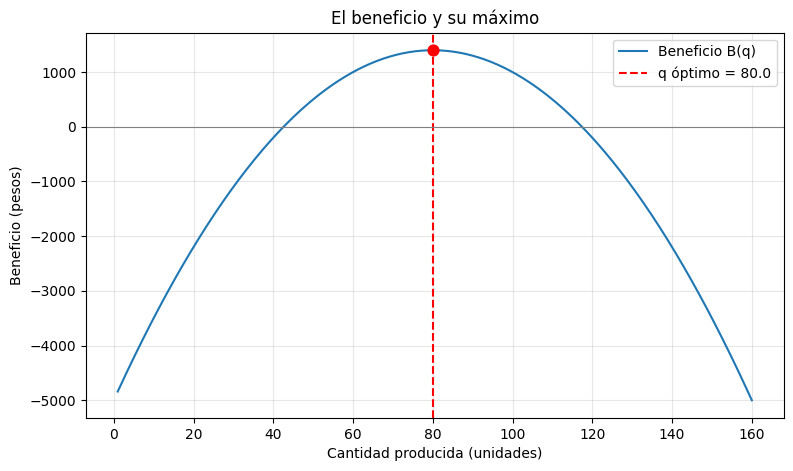

In [ ]:
# Visualizamos el óptimo: convertimos la expresión simbólica a numérica con lambdify
B_num = sp.lambdify(q, B, "numpy")
qs = np.linspace(1, 160, 400)

plt.figure(figsize=(9, 5))
plt.plot(qs, B_num(qs), label="Beneficio B(q)")
plt.axvline(float(q_opt), color="red", linestyle="--",
            label=f"q óptimo = {float(q_opt):.1f}")
plt.axhline(0, color="gray", linewidth=0.8)
plt.scatter([float(q_opt)], [float(B.subs(q, q_opt))], color="red", zorder=5, s=60)
plt.title("El beneficio y su máximo")
plt.xlabel("Cantidad producida (unidades)")
plt.ylabel("Beneficio (pesos)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
# ⚖️ Bloque 5 — Marginales y elasticidades

## Marginal = derivada del total

| Marginal | Se obtiene derivando | Qué responde |
|---|---|---|
| **Costo marginal** $CMg$ | $CT'(q)$ | ¿Cuánto **cuesta** la unidad siguiente? |
| **Ingreso marginal** $IMg$ | $IT'(q)$ | ¿Cuánto **entra** por la unidad siguiente? |
| **Beneficio marginal** $BMg$ | $B'(q) = IMg - CMg$ | ¿Cuánto **suma al resultado** la unidad siguiente? |

## 🎯 La regla de oro: $IMg = CMg$

El beneficio es máximo cuando el **ingreso marginal se iguala al costo marginal**. Y es lógico:

- Si $IMg > CMg$, la unidad siguiente **deja plata** → conviene producirla.
- Si $IMg < CMg$, la unidad siguiente **cuesta más de lo que trae** → conviene no producirla.
- El punto donde se cruzan es donde ya no se puede mejorar: es el **óptimo**.

> 💡 Esto es **exactamente lo mismo** que igualar $B'(q) = 0$, porque $B' = IMg - CMg$. Son dos
> caminos al mismo número, y en el parcial cualquiera de los dos sirve **si está justificado**.

In [ ]:
# Los marginales del mismo caso
CMg = sp.diff(CT, q)
IMg = sp.diff(IT, q)

print("CMg(q) =", CMg)
print("IMg(q) =", IMg)

# El óptimo por la regla IMg = CMg
q_regla = sp.solve(sp.Eq(IMg, CMg), q)[0]
print("\nDonde IMg = CMg ->  q =", round(float(q_regla), 2))
print("Por B'(q) = 0    ->  q =", round(float(q_opt), 2), " <- el mismo número")

# Lectura de una unidad más, en el óptimo
print("\nEn el óptimo: CMg = $", round(float(CMg.subs(q, q_regla)), 2),
      " | IMg = $", round(float(IMg.subs(q, q_regla)), 2))

CMg(q) = 1.0*q + 40
IMg(q) = 200 - 1.0*q

Donde IMg = CMg ->  q = 80.0
Por B'(q) = 0    ->  q = 80.0  <- el mismo número

En el óptimo: CMg = $ 120.0  | IMg = $ 120.0


## 📐 Elasticidad: cuánto reacciona la cantidad

La elasticidad mide **cuánto reacciona una variable cuando cambia otra**, siempre en **términos
porcentuales**. Por eso no tiene unidades: es un número puro y se puede comparar entre productos
distintos (kilos de pan con litros de nafta).

$$\text{elasticidad} = \frac{\%\ \text{cambio en la cantidad}}{\%\ \text{cambio en la otra variable}}$$

Según cuál sea esa "otra variable" hay tres elasticidades, y **cada una responde una pregunta de
gestión distinta**.

---

### 1️⃣ Elasticidad precio de la demanda ($\epsilon_p$)

*Si cambia **el precio de mi producto**, ¿cuánto cambia la cantidad que me compran?*

$$\epsilon_p = \frac{\%\Delta q}{\%\Delta p} = \frac{dq}{dp}\cdot\frac{p}{q}$$

Casi siempre da **negativa**, porque si el precio sube la cantidad baja (es la ley de demanda). Como
el signo es siempre el mismo y no agrega información, **se la clasifica por su valor absoluto**
$\lvert \epsilon_p \rvert$, es decir sin mirar el signo.

| Valor | Cómo se llama | En castellano | Si **subo** el precio, el ingreso… |
|---|---|---|---|
| $\lvert \epsilon_p \rvert = 0$ | **Perfectamente inelástica** | La cantidad **no se mueve** por más que cambie el precio | **Sube** (caso extremo) |
| $0 < \lvert \epsilon_p \rvert < 1$ | **Inelástica** | La cantidad reacciona **menos** que el precio | **Sube** |
| $\lvert \epsilon_p \rvert = 1$ | **Unitaria** | La cantidad reacciona **exactamente igual** que el precio | **No cambia**: está en su máximo |
| $\lvert \epsilon_p \rvert > 1$ | **Elástica** | La cantidad reacciona **más** que el precio | **Baja** |
| $\lvert \epsilon_p \rvert \to \infty$ | **Perfectamente elástica** | Con el mínimo aumento **te quedás sin clientes** | **Se derrumba** (caso extremo) |

**Cómo se entiende sin fórmulas.** Lo que decide todo es **quién se mueve más**, si el precio o la
cantidad:

- **Inelástica**: el cliente compra igual aunque aumente. Pasa con lo que **no se puede dejar de
  comprar ni reemplazar fácil**: sal, medicamentos, el boleto para ir a trabajar. Como pierdo pocos
  clientes, **aumentar el precio me deja más ingreso**.
- **Elástica**: el cliente se va apenas aumento. Pasa con lo que **tiene sustitutos a mano** o se
  puede postergar: una marca puntual de gaseosa, un viaje de placer, un televisor. Acá **aumentar el
  precio me hace perder ingreso**.
- **Unitaria**: lo que gano por el precio más alto es exactamente lo que pierdo por vender menos. El
  ingreso **no se mueve**, y justamente ahí está su punto más alto.

> 💡 **Qué la hace elástica o inelástica:** que existan **sustitutos** (cuantos más, más elástica),
> que sea un **gasto grande** del presupuesto, que sea un **lujo** en lugar de una necesidad, y el
> **tiempo** (a largo plazo todo se vuelve más elástico, porque el cliente encuentra alternativas).

**Las dos formas de calcularla**

| Forma | Cuándo se usa | Fórmula |
|---|---|---|
| **Puntual** (continua) | Tengo la **función** de demanda y quiero la elasticidad **en un punto** | $\epsilon_p = \dfrac{dq}{dp}\cdot\dfrac{p}{q}$ |
| **Arco** (discreta) | Tengo **dos observaciones** (dos precios y dos cantidades) | Se usan el precio y la cantidad **promedio** entre los dos puntos |

> ⚠️ La de **arco** usa los promedios justamente para que dé lo mismo ir de A hacia B que de B hacia
> A. Si se calcula con el punto de partida, la subida y la bajada dan distinto.

---

### 2️⃣ Elasticidad cruzada ($\epsilon_{xy}$): sustitutos y complementarios

*Si cambia el precio de **otro** producto, ¿cuánto cambia la cantidad que me compran **a mí**?*

$$\epsilon_{xy} = \frac{\%\Delta q_x}{\%\Delta p_y}$$

Acá **el signo es lo único que importa**, porque dice qué relación tienen los dos bienes:

| Signo | Relación | Qué significa | Ejemplo |
|---|---|---|---|
| $\epsilon_{xy} > 0$ | **Sustitutos** | Si el otro **aumenta**, me compran **más a mí**: el cliente se cambia | Café y té; dos marcas de gaseosa; colectivo y subte |
| $\epsilon_{xy} < 0$ | **Complementarios** | Si el otro **aumenta**, me compran **menos a mí**: se consumen juntos | Impresora y cartuchos; auto y nafta; pan y manteca |
| $\epsilon_{xy} = 0$ | **Independientes** | No tienen nada que ver entre sí | Zapatillas y harina |

> 💡 **La forma fácil de acordarse:** **sustitutos compiten** (uno reemplaza al otro, van en
> direcciones opuestas y el signo sale **positivo**); **complementarios se acompañan** (caen juntos y
> el signo sale **negativo**).

---

### 3️⃣ Elasticidad ingreso ($\epsilon_i$): bienes normales e inferiores

*Si a la gente **le cambia el ingreso**, ¿cuánto cambia la cantidad que compra?*

$$\epsilon_i = \frac{\%\Delta q}{\%\Delta \text{ingreso}}$$

| Valor | Tipo de bien | Qué significa | Ejemplo |
|---|---|---|---|
| $\epsilon_i > 1$ | **Normal de lujo** | Si el ingreso sube, el consumo sube **todavía más** | Viajes, autos 0 km, restaurantes |
| $0 < \epsilon_i < 1$ | **Normal de primera necesidad** | El consumo sube, pero **menos** que el ingreso | Pan, luz, transporte |
| $\epsilon_i < 0$ | **Inferior** | Si el ingreso sube, el consumo **baja**: se reemplaza por algo mejor | Segundas marcas |

---

### 🎯 La pregunta de parcial

No suele ser "calculá la elasticidad", sino **decidir con ella**:

> *"¿Conviene subir el precio?"* → Si la demanda es **inelástica**, **sí**: se pierden pocas ventas y
> el ingreso sube. Si es **elástica**, **no**: la caída de cantidad se come el aumento.

Y la versión cruzada: *"¿este competidor me afecta?"* → si la elasticidad cruzada es **positiva**,
son **sustitutos** y su aumento de precio te favorece.

> 📌 **Siempre cerrá con la decisión**, no con el número. "La elasticidad es $-0{,}4$" no es una
> respuesta; "es inelástica, así que conviene subir el precio porque el ingreso aumenta" sí lo es.

---

> 🤓 **PD para curiosos: el bien Giffen**
>
> Dijimos que la elasticidad precio es negativa **casi siempre**. El bien **Giffen** es la excepción
> teórica: un bien tan básico y tan barato, para gente con un presupuesto tan ajustado, que **cuando
> su precio sube se consume más**, no menos.
>
> La lógica: si el alimento básico que sostiene la dieta se encarece, el bolsillo queda tan golpeado
> que hay que **resignar lo más caro** (la carne, por ejemplo) y compensar comprando **todavía más**
> del básico. El efecto ingreso termina siendo más fuerte que el efecto sustitución, y la curva de
> demanda queda con **pendiente positiva**.
>
> Es un caso raro y muy discutido: todo bien Giffen es inferior, pero casi ningún bien inferior es
> Giffen. **No entra en el parcial**, pero es la razón por la que decimos "casi siempre" y no
> "siempre". 🥔

---
# 📊 Bloque 6 — Programación lineal: `linprog` y `PuLP`

## Anatomía de un problema de PL

Todo problema de programación lineal se plantea con las mismas cuatro piezas. **Escribirlas
explícitamente es lo que se corrige** en el parcial:

| Pieza | Qué es | Ejemplo |
|---|---|---|
| **Variables de decisión** | Lo que la organización elige, **con unidades** | $x$ = kilos de pan por día |
| **Función objetivo** | Lo que se maximiza o minimiza | $\max\ 120x + 200y$ |
| **Restricciones** | Los límites de recursos | $x + 2y \le 160$ (horas de horno) |
| **No negatividad** | No se produce en negativo | $x \ge 0,\ y \ge 0$ |

Vamos con un caso concreto para los dos solvers:

> **Caso.** Una panadería hace **pan** ($x$) y **facturas** ($y$), en kilos por día. El pan deja
> \$120 por kilo y las facturas \$200. Cada kilo de pan usa 1 hora de horno y 3 kg de masa; cada kilo
> de facturas, 2 horas de horno y 2 kg de masa. Hay **160 horas** de horno y **300 kg** de masa por
> día. ¿Cuánto conviene producir de cada cosa?

In [ ]:
# ---------- Con linprog (SciPy) ----------
# OJO: linprog SIEMPRE minimiza. Para MAXIMIZAR hay que poner los coeficientes en NEGATIVO.
c = [-120, -200]                    # maximizar 120x + 200y  ->  minimizar -120x - 200y

A_ub = [[1, 2],                     # horno:  1x + 2y <= 160
        [3, 2]]                     # masa:   3x + 2y <= 300
b_ub = [160, 300]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None), (0, None)], method="highs")

print(res)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -17400.0
              x: [ 7.000e+01  4.500e+01]
            nit: 2
          lower:  residual: [ 7.000e+01  4.500e+01]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00]
                 marginals: [-9.000e+01 -1.000e+01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0


## 🔍 Cómo se lee la salida de `linprog`

Esta lectura es pregunta directa de parcial. Campo por campo:

| Campo | Qué dice | En este caso |
|---|---|---|
| `message` / `status` | Si encontró la solución. `status: 0` es óptimo | Terminó bien |
| `success` | `True` si hay solución óptima | `True` |
| **`fun`** | El valor de la función objetivo **minimizada** | Viene **negativo**: la ganancia real es su valor absoluto |
| **`x`** | Los valores óptimos de las variables, **en el orden en que las declaré** | `[70, 45]` → 70 kg de pan, 45 de facturas |
| `nit` | Iteraciones que hizo el algoritmo | Dato técnico, no se interpreta |
| `marginals` | Cuánto mejora el objetivo si se afloja una restricción (precio sombra) | Fuera del alcance del parcial |

> ⚠️ **La trampa del signo.** Como pusimos `c` en negativo para maximizar, `fun` sale negativo. La
> ganancia es $|fun|$. Si en el parcial aparece un `fun` negativo en un problema de maximización,
> **eso no es un error**: es la consecuencia de que `linprog` minimiza siempre.

> 📌 **El orden de `x` es el orden en que declaraste las variables.** `x: [70, 45]` no dice "pan" ni
> "facturas": lo dice tu planteo. Por eso el paso de definir las variables **con unidades** es parte
> de la respuesta.

In [ ]:
# Interpretación explícita de la salida de arriba
pan, facturas = res.x
print(f"Producir {pan:.0f} kg de pan y {facturas:.0f} kg de facturas por día.")
print(f"Ganancia máxima: ${-res.fun:,.0f} por día   <- ojo el signo: -fun")

# ¿Los recursos se usan del todo?
horno_usado = 1*pan + 2*facturas
masa_usada  = 3*pan + 2*facturas
print(f"\nHorno: {horno_usado:.0f} de 160 horas usadas")
print(f"Masa:  {masa_usada:.0f} de 300 kg usados")
print("\nLas dos restricciones se usan completas: son restricciones ACTIVAS.")

Producir 70 kg de pan y 45 kg de facturas por día.
Ganancia máxima: $17,400 por día   <- ojo el signo: -fun

Horno: 160 de 160 horas usadas
Masa:  300 de 300 kg usados

Las dos restricciones se usan completas: son restricciones ACTIVAS.


In [ ]:
# ---------- El MISMO problema con PuLP ----------
if PULP_OK:
    # 1) El problema: acá se dice explícitamente que es de MAXIMIZAR (sin trucos de signo)
    modelo = pulp.LpProblem("panaderia", pulp.LpMaximize)

    # 2) Las variables, con su nombre y su cota inferior
    x = pulp.LpVariable("pan",      lowBound=0)
    y = pulp.LpVariable("facturas", lowBound=0)

    # 3) La función objetivo
    modelo += 120*x + 200*y, "ganancia"

    # 4) Las restricciones, con nombre
    modelo += 1*x + 2*y <= 160, "horno"
    modelo += 3*x + 2*y <= 300, "masa"

    # 5) Resolver
    modelo.solve(pulp.PULP_CBC_CMD(msg=0))

    print("Estado:", pulp.LpStatus[modelo.status])
    print(f"Pan:      {x.value():.0f} kg")
    print(f"Facturas: {y.value():.0f} kg")
    print(f"Ganancia: ${pulp.value(modelo.objective):,.0f}   <- positiva, sin dar vuelta el signo")
else:
    print("PuLP no está instalado. Instalalo con: !pip install pulp -q")

Estado: Optimal
Pan:      70 kg
Facturas: 45 kg
Ganancia: $17,400   <- positiva, sin dar vuelta el signo


## ⚔️ `linprog` contra `PuLP`: pros y contras

Los dos resuelven el mismo problema y dan el mismo resultado. Lo que cambia es **cómo se escribe** y
**qué tan legible queda**:

| | `linprog` (SciPy) | `PuLP` |
|---|---|---|
| **Cómo se plantea** | Con **listas y matrices**: `c`, `A_ub`, `b_ub` | Con **variables con nombre** y ecuaciones |
| **Maximizar** | Hay que poner los coeficientes en **negativo** | Se declara `LpMaximize`, sin trucos |
| **Legibilidad** | Baja: hay que recordar qué columna es cada variable | Alta: se lee casi como el planteo matemático |
| **Ventaja** | Rápido y viene con SciPy, sin instalar nada | Claro, con nombres y restricciones etiquetadas |
| **Desventaja** | Se presta a errores de orden y de signo | Hay que instalarlo (`pip install pulp`) |
| **Variables enteras** | No las maneja | **Sí** (`cat="Integer"`): sirve para "no puedo contratar media persona" |
| **Cuándo usar cada uno** | Problemas chicos, cuentas rápidas | Modelos con varias variables, o si hay que leerlo después |

> 💡 **Si en el parcial piden justificar la elección:** `PuLP` se defiende por **claridad y
> trazabilidad** del modelo (y porque permite variables enteras); `linprog` se defiende por ser
> **directo y sin dependencias**. Las dos respuestas son válidas si se argumenta.

> ⚠️ **Errores clásicos de PL**
>
> | Error | Consecuencia |
> |---|---|
> | Olvidarse del negativo en `c` al maximizar con `linprog` | Se minimiza la ganancia: da la peor solución |
> | Dejar una restricción como $\ge$ cuando `A_ub` espera $\le$ | Hay que multiplicar la fila por $-1$; si no, el modelo es otro |
> | Mezclar unidades (horas con kilos) | El modelo corre igual y el resultado no tiene sentido |
> | No declarar la no negatividad | Aparecen producciones negativas |
> | No interpretar el resultado | Queda un número sin respuesta de gestión: no puntúa |

---
# 🗂️ Cuadros resumen (para los días que quedan)

## Cuadro 1 — Qué herramienta va con cada pregunta

| Si la pregunta es... | La herramienta es | Se ve en la clase |
|---|---|---|
| ¿Cuánto cambia esto si aumenta una unidad? | Derivada: `sp.diff` | 09, 10 |
| ¿Cuál es la cantidad óptima? | Derivar, igualar a cero, verificar 2ª derivada | 11 |
| ¿Cuánto conviene producir con recursos limitados? | Programación lineal: `linprog` / `PuLP` | 08 |
| ¿Cuánto de cada cosa, si todo tiene que cerrar exacto? | Sistema de ecuaciones: `np.linalg.solve` | 07 |
| ¿Cuál es el total de esta tabla, por fila o por columna? | `axis=0` / `axis=1` | 05 |
| ¿Cuánto facturó en total? | Producto matricial `@` | 05 |
| ¿Qué filas cumplen esta condición? | Máscara booleana | 06 |
| ¿Cuánto por categoría? | `groupby` | 06 |
| ¿Dónde se cruzan oferta y demanda? | `sp.solve` sobre la igualdad | 04 |
| ¿Qué me dice este gráfico? | Interpretación: arranque, cruces, máximo, pendiente | 02, 03 |

## Cuadro 2 — Las fórmulas que hay que saber de memoria

| Concepto | Fórmula |
|---|---|
| Costo total | $CT = CF + CV(q)$ |
| Costo medio | $CMe = CT/q$ |
| Costo marginal | $CMg = CT'(q)$ |
| Ingreso total | $IT = p \cdot q$ |
| Ingreso marginal | $IMg = IT'(q)$ |
| Beneficio | $B = IT - CT$ |
| **Óptimo** | $B'(q) = 0$, o bien $IMg = CMg$ |
| Máximo confirmado | $B''(q) < 0$ |
| Mínimo confirmado | $B''(q) > 0$ |
| Punto de nivelación | $IT = CT$, es decir $B = 0$ |
| Elasticidad | $\epsilon_p = \dfrac{\%\Delta q}{\%\Delta p}$ |

## Cuadro 3 — Los pares que se confunden

| | |
|---|---|
| `*` (elemento a elemento) | `@` (multiplica y **suma**: total) |
| `axis=0` (resultado **por columna**) | `axis=1` (resultado **por fila**) |
| `.loc` (por **etiqueta**, final incluido) | `.iloc` (por **posición**, final excluido) |
| `df["col"]` (`Series`) | `df[["col"]]` (`DataFrame`) |
| Costo **medio** (divide) | Costo **marginal** (deriva) |
| `&` (y, entre columnas) | `and` (no funciona con columnas) |
| `linprog` (minimiza siempre) | `PuLP` (se declara `LpMaximize`) |
| 1ª derivada (¿dónde está el candidato?) | 2ª derivada (¿es máximo o mínimo?) |

---
# 🧘 Cómo encarar el parcial

Para muchos de ustedes este es el **primer examen universitario**, y eso pesa más que el contenido.
Van algunas cosas que sirven de verdad.

## Antes de arrancar

- **Leé todo el examen** antes de escribir la primera palabra: los ejercicios suelen ir sobre un
  mismo caso, y saber para dónde va la historia ayuda a responder el primero.
- **Arrancá por el ejercicio que te sale.** No hay ningún premio por hacerlos en orden, y empezar
  resolviendo algo te ordena la cabeza.
- **Dentro de cada ejercicio, los incisos van de menor a mayor dificultad.** El (a) es el más
  accesible: es un buen lugar para empezar.

## Mientras lo hacés

- **Escribí el planteo, siempre.** Variables con unidades, qué función estás usando y por qué. Toda
  respuesta numérica sin justificación vale **cero**, y el procedimiento puntúa incluso si el número
  final sale mal.
- **Poné las unidades en cada resultado.** "80" no es una respuesta; "80 unidades por día" sí.
- **Cerrá con una frase de interpretación.** Lo que más pesa en la corrección es la lectura
  económica: después de cada cuenta, una línea que diga qué significa para la empresa del caso.
- **Si te trabás, pasá al siguiente.** Quedarse 40 minutos en un inciso es la forma más común de
  perder puntos que estaban a mano. Marcalo y volvé después.
- **Si no te sale la cuenta, explicá el camino.** "Habría que derivar el beneficio, igualarlo a cero
  y verificar con la segunda derivada" muestra que entendiste el procedimiento, y eso se corrige.

## Lo operativo (que también puntúa)

- Son **3 horas**, pensado para resolverse en **2:30**. Los últimos 30 minutos son para **revisar**.
- **Todas las hojas** con nombre, apellido y número de registro, numeradas y ordenadas.
- Indicá claramente **número de ejercicio e inciso** en cada respuesta.
- Se permite **calculadora científica no programable**. No se permiten apuntes, resúmenes, notebooks
  de la cátedra, celular ni asistentes de IA.
- Se admite **redondeo razonable**.

> 💡 **Y algo que no es menor:** respirá. Si te bloqueás, soltá la lapicera treinta segundos y mirá
> otro ejercicio. Le pasa a todo el mundo en el primer parcial, y no dice nada sobre lo que sabés.

---
# 📝 Ejercicios de práctica

Cuatro ejercicios integradores, **más difíciles que lo que van a encontrar el martes**. Si estos
salen, el parcial sobra.

> ⚠️ **Hacelos en papel primero**, sin correr nada, y recién después abrí la resolución. Correr el
> código antes de pensarlo es la mejor forma de creer que entendiste algo que no entendiste.

### El caso: **Los Álamos S.A.**

Planta de **alimento balanceado** en Santa Fe. Vende a distribuidoras (canal *súper*), a
veterinarias (canal *resto*) y ocasionalmente exporta. Los cuatro ejercicios van sobre esta empresa.

---
### ✅ Ejercicio 1 — Datos, depuración y atípicos

La tabla `despachos` de junio, sin depurar:

| op | fecha | cliente | canal | kg | precio_kg | importe |
|---|---|---|---|---|---|---|
| A-01 | 03-06 | Distrib. Litoral | super | 400 | 1.800 | 720.000 |
| A-02 | 05-06 | Veterinaria Sur | resto | 150 | 2.400 | 360.000 |
| A-03 | 09-06 | Agro Export | export | 9.000 | 1.500 | 13.500.000 |
| A-04 | 12-06 | Distrib. Litoral | SUPER | 200 | 1.800 | 360.000 |
| A-05 | 15-06 | Veterinaria Sur | resto | 120 | 2.400 | 288.000 |
| A-06 | 18-06 | Distrib. Litoral | super | 300 | 1.800 | **54.000** |

**a)** Hay **una fila cuyo importe no puede ser correcto**, y no se detecta comparándola con las
demás sino **con la propia fila**. Identificala, explicá con qué cuenta te diste cuenta y decidí qué
harías con ella.

**b)** El siguiente bloque tiene **tres errores**. Dos rompen el programa; el tercero **corre igual y
devuelve un número equivocado**, que es el más peligroso. Identificá los tres y explicá cuál es el
silencioso y por qué es el más grave.

```python
promedio = despachos["importe"].mean                                        # (1)
grandes  = despachos[despachos["kg"] > 200 & despachos["canal"] == "super"] # (2)
total    = despachos["importe"].sum()                                       # (3)
```

**c)** En esta tabla hay **dos valores que se salen del resto**: el de A-03 y el de A-06.
**Solo uno de los dos se excluye del análisis.** Explicá cuál, por qué, y qué habría que hacer con
el otro.

In [ ]:
# Ejercicio 1 — armá acá la tabla y probá tus respuestas
import pandas as pd

despachos = pd.DataFrame({
    "op":        ["A-01", "A-02", "A-03", "A-04", "A-05", "A-06"],
    "cliente":   ["Distrib. Litoral", "Veterinaria Sur", "Agro Export",
                  "Distrib. Litoral", "Veterinaria Sur", "Distrib. Litoral"],
    "canal":     ["super", "resto", "export", "SUPER", "resto", "super"],
    "kg":        [400, 150, 9000, 200, 120, 300],
    "precio_kg": [1800, 2400, 1500, 1800, 2400, 1800],
    "importe":   [720000, 360000, 13500000, 360000, 288000, 54000],
})

# Pista para el inciso a): ¿qué pasa si comparás importe con kg * precio_kg?

<details>
<summary><b>🔑 Ver resolución del Ejercicio 1</b></summary>

**a) La fila A-06.** No se detecta comparándola con las otras —\$54.000 es un importe chico, no
llama la atención— sino **verificando la consistencia interna de la propia fila**:

$$\text{kg} \times \text{precio\_kg} = 300 \times 1.800 = 540.000 \neq 54.000$$

Al importe **le falta un cero**: es un error de tipeo. Y acá corresponde **corregirlo**, no borrar la
fila: los datos para reconstruirlo están en la misma fila. La cuenta
`(kg * precio_kg) - importe` sobre toda la tabla encuentra este tipo de error en un segundo.

> 💡 Este control —recalcular una columna que se puede derivar de otras— es de los más útiles que
> existen y casi nadie lo hace.

**b) Los tres errores:**

1. **`.mean` sin paréntesis** — no llama al método: guarda el objeto método en lugar del promedio.
   Va `.mean()`. Se nota al imprimir: sale algo tipo `<bound method ...>`.
2. **Falta de paréntesis en el filtro** — `&` tiene **más precedencia** que `>` y `==`, así que
   Python intenta evaluar `200 & despachos["canal"]` y falla. Va
   `(despachos["kg"] > 200) & (despachos["canal"] == "super")`. *(Y aun corregido, deja afuera
   `SUPER` de A-04 por el formato.)*
3. **El silencioso: `despachos["importe"].sum()`.** La línea es **correcta**; el problema es que
   **los datos no lo son**. Devuelve **\$15.282.000**, cuando la facturación real es
   **\$15.768.000**: se pierden los \$486.000 del error de A-06.

**Por qué el tercero es el más grave:** los dos primeros **rompen el programa**, así que se arreglan
en el momento. El tercero corre sin protestar y **devuelve un número con pinta de razonable**. Si
nadie recalculó la consistencia de la tabla, ese \$15.282.000 llega al informe del directorio y nadie
se entera nunca.

> 📌 **La moraleja:** que el código no dé error **no significa que el resultado esté bien**. Un
> número correcto necesita código correcto **y** datos correctos.

**c) Se excluye A-06, no A-03** —y solo hasta que se corrija:

- **A-03 (Agro Export, \$13.500.000)** es un valor atípico **legítimo**: una exportación de 9.000 kg
  a un precio menor por kilo. Es un caso real de otro canal. **No se borra**: se analiza
  **por separado** del mercado interno, porque mezclarla distorsiona cualquier promedio.
- **A-06** es un atípico por **error de carga**, el del inciso a). Lo correcto no es ni siquiera
  excluirlo: es **corregirlo** a \$540.000 y devolverlo al análisis.

> 📌 **La distinción que se evalúa:** un valor raro puede ser un *error* (se corrige o se saca) o un
> *caso real distinto* (se conserva y se analiza aparte). Decidirlo **no es una cuenta, es criterio**.

</details>

---
### ✅ Ejercicio 2 — Marginales y decisión de producción

Para la línea principal, con $q$ en **toneladas por mes** y los importes en **miles de pesos**:

$$CT(q) = \tfrac{1}{4}q^2 + 20q + 1600 \qquad\qquad p(q) = 200 - q$$

En la reunión de directorio aparecen **tres posturas distintas**:

- **Comercial** quiere producir **100 toneladas**: "es el nivel que maximiza la facturación".
- **Producción** quiere **80 toneladas**: "es donde el costo por tonelada es el más bajo posible".
- **Análisis de datos** dice que ninguna de las dos.

**a)** Escribí $IT(q)$, $B(q)$, $CMg(q)$, $IMg(q)$ y el **costo medio** $CMe(q)$.

**b)** Verificá las dos afirmaciones: ¿es cierto que en 100 toneladas se maximiza la facturación?
¿Y que en 80 el costo por tonelada es el mínimo? Justificá cada una **derivando**.

**c)** Hallá la cantidad que maximiza el **beneficio**, verificá con la condición de segundo orden y
comprobá que ahí $IMg = CMg$.

**d)** Calculá el beneficio en los **tres** niveles y ordenalos.

**e)** La pregunta difícil: **¿por qué el máximo del beneficio no coincide con el mínimo del costo
medio**, si producir al menor costo unitario parece lo más eficiente? Respondé en tres o cuatro
líneas.

In [ ]:
# Ejercicio 2 — resolvé acá
import sympy as sp

q = sp.symbols("q", positive=True)
CT = sp.Rational(1, 4)*q**2 + 20*q + 1600
p  = 200 - q

# IT, B, CMg, IMg, CMe ...

<details>
<summary><b>🔑 Ver resolución del Ejercicio 2</b></summary>

**a)** $IT = p \cdot q = 200q - q^2$ y $B = IT - CT = -1{,}25q^2 + 180q - 1600$.
$$CMg = CT'(q) = \tfrac{1}{2}q + 20 \qquad IMg = IT'(q) = 200 - 2q \qquad CMe = \frac{CT}{q} = \frac{q}{4} + 20 + \frac{1600}{q}$$

**b) Las dos afirmaciones son ciertas**, y se verifican derivando:

- **Comercial:** $IT' = 200 - 2q = 0 \Rightarrow q = 100$. Efectivamente ahí la **facturación** es
  máxima: $IT(100) = 10.000$.
- **Producción:** $CMe' = \tfrac{1}{4} - \dfrac{1600}{q^2} = 0 \Rightarrow q^2 = 6.400 \Rightarrow
  q = 80$. Ahí el costo por tonelada toca su mínimo: $CMe(80) = 60$.
  *(Dato lindo: en ese punto $CMg(80) = 60$ también. **El costo marginal siempre corta al costo medio
  justo en su mínimo**, y no es casualidad: mientras la unidad siguiente cueste menos que el promedio,
  el promedio baja.)*

**c) El máximo del beneficio:**
$$B'(q) = -2{,}5q + 180 = 0 \;\Rightarrow\; \mathbf{q^* = 72} \qquad B''(q) = -2{,}5 < 0 \;\Rightarrow\; \textbf{es un máximo}$$
Y en ese punto: $IMg(72) = 200 - 144 = 56$ y $CMg(72) = 36 + 20 = 56$. ✔

**d) Los tres beneficios:**

| Postura | $q$ | Beneficio | Precio |
|---|---|---|---|
| **Análisis (máx. beneficio)** | 72 | **4.880** | 128 |
| Producción (mín. costo medio) | 80 | 4.800 | 120 |
| Comercial (máx. facturación) | 100 | 3.900 | 100 |

**e) Por qué el óptimo no está en el mínimo del costo medio.** Porque **minimizar el costo por unidad
no es el objetivo de la empresa: maximizar el beneficio sí**. El costo medio solo mira los costos e
ignora por completo lo que pasa con el ingreso. Al pasar de 72 a 80 toneladas el costo por tonelada
mejora, pero para colocar esas 8 toneladas extra hay que bajar el precio de 128 a 120, y **lo que se
pierde por el lado del ingreso es mayor que lo que se ahorra por el lado del costo**: el beneficio
cae de 4.880 a 4.800. Producir barato no sirve de nada si para vender esa producción hay que resignar
más de lo que se ahorró.

> 🧠 **La moraleja:** las tres áreas tienen razón *en su propio indicador*. Comercial maximiza
> facturación, Producción minimiza costo unitario, y las dos cosas son ciertas. Pero el único
> indicador que integra ingresos y costos es el **beneficio**, y por eso es el que manda.

</details>

---
### ✅ Ejercicio 3 — Opción múltiple

Una sola opción correcta en cada una. Ojo que son más retorcidas de lo que parecen.

---

**3.1** La planta tiene una matriz `R` de **horas por tonelada**, con las **etapas en las filas** y
las **líneas de producto en las columnas**, y un vector `plan` con las **toneladas** de cada línea:

```python
R    = np.array([[2, 3, 4],      # prensado
                 [2, 2, 3],      # pasteurizado
                 [1, 2, 2]])     # envasado
plan = np.array([30, 20, 20])    # toneladas de cada linea
```

Se ejecuta `R @ plan`. ¿Qué devuelve?

&nbsp;&nbsp;&nbsp;(a) 3 valores: las **horas** que consume el plan en cada etapa
&nbsp;&nbsp;&nbsp;(b) 3 valores: las **toneladas** que produce cada línea
&nbsp;&nbsp;&nbsp;(c) un solo número: el total de horas

---

**3.2** Para averiguar cuánto producir de cada línea se plantea un sistema de ecuaciones y se
resuelve con `np.linalg.solve(A, b)`. Pero la matriz `A` tiene **determinante cero**. Al correr esa
línea, Python:

&nbsp;&nbsp;&nbsp;(a) devuelve la solución más cercana posible
&nbsp;&nbsp;&nbsp;(b) **lanza un error**: la matriz es singular
&nbsp;&nbsp;&nbsp;(c) devuelve un vector de ceros

---

**3.3** En un gráfico de costo total e ingreso total, las dos curvas **se cruzan en dos puntos**. En
el **segundo** de esos cruces:

&nbsp;&nbsp;&nbsp;(a) el beneficio es máximo
&nbsp;&nbsp;&nbsp;(b) el ingreso es máximo
&nbsp;&nbsp;&nbsp;(c) el beneficio es cero

---

**3.4** Se filtra la tabla de despachos buscando operaciones de más de 50.000 kg, pero **ninguna
llega a ese volumen**:

```python
grandes = despachos[despachos["kg"] > 50000]
```

¿Qué queda en `grandes`?

&nbsp;&nbsp;&nbsp;(a) el filtro lanza un error porque no encontró nada
&nbsp;&nbsp;&nbsp;(b) un `DataFrame` **vacío**: conserva las columnas pero no tiene ninguna fila
&nbsp;&nbsp;&nbsp;(c) `None`

---

**3.5** Un `DataFrame` tiene como índice los códigos `"A-01"`, `"A-02"`, `"A-03"`, `"A-04"`. Se
ejecuta `df.loc["A-01":"A-03"]` y `df.iloc[0:3]`. Devuelven, respectivamente:

&nbsp;&nbsp;&nbsp;(a) 3 y 3 filas &nbsp;&nbsp;&nbsp; (b) 3 y 2 filas &nbsp;&nbsp;&nbsp; (c) 2 y 3 filas


<details>
<summary><b>🔑 Ver resolución del Ejercicio 3</b></summary>

**3.1 → (a) 3 valores: las horas de cada etapa.** `R @ plan` multiplica **cada fila** de la matriz
(una etapa) por el plan y suma: devuelve `[200, 160, 110]`, o sea las horas de prensado,
pasteurizado y envasado. La (b) confunde entrada con salida: las toneladas **son** el vector que se
multiplica, no el resultado.

> ⚠️ **El detalle peligroso:** `plan @ R` también corre —la matriz es cuadrada— y devuelve
> `[120, 170, 220]`. Pero ese número **no significa nada**: mezcla horas de etapas distintas. Como no
> falla, el error pasa desapercibido.

**3.2 → (b) lanza un error.** Determinante cero significa que la matriz es **singular**: las
ecuaciones no son independientes (una es combinación de las otras), así que el sistema **no tiene
solución única**. `np.linalg.solve` no inventa una respuesta: corta con
`LinAlgError: Singular matrix`. Es la razón por la que conviene **mirar el determinante antes** de
resolver.

**3.3 → (c) el beneficio es cero.** Donde el ingreso total iguala al costo total no se gana ni se
pierde: son los **puntos de nivelación**. Hay dos porque el beneficio primero crece, pasa por su
máximo y después vuelve a caer: el segundo cruce es donde **se deja de ganar**. La (a) es el error
clásico: el máximo del beneficio está **entre** los dos cruces, no en ellos —- ahí la distancia entre
las curvas es la más grande, no cero.

**3.4 → (b) un `DataFrame` vacío.** Un filtro que no encuentra nada **no es un error**: devuelve una
tabla con las mismas columnas y **cero filas** (forma `(0, 2)`). Se comprueba con `len(grandes)`, que
da 0, o con `grandes.empty`, que da `True`.

> 📌 **Por qué importa:** si después calculás `grandes["importe"].mean()` sobre esa tabla vacía, el
> resultado es `NaN` y **tampoco falla**. Un filtro demasiado exigente puede vaciar la tabla sin que
> nada avise: por eso hay que **contar las filas que quedaron** siempre.

**3.5 → (a) 3 y 3 filas.** Esta es la trampa: aunque el índice sea de texto, `.loc` **incluye el
final**, así que `"A-01":"A-03"` trae tres. Y `.iloc[0:3]` **excluye** el final, pero como arranca en
0 trae las posiciones 0, 1 y 2: también tres. **Coinciden por casualidad**, no porque funcionen
igual. Con `.loc["A-01":"A-04"]` serían 4 y con `.iloc[0:4]`, 4: el que cambia de comportamiento es
siempre el mismo.

</details>


---
### ✅ Ejercicio 4 — El cierre integrador

**Este es el ejercicio que más gente subestima**, y el que más rinde practicar.

Con **todo lo que analizaste en los ejercicios 1 a 3**, escribí **un párrafo** dirigido al directorio
de Los Álamos S.A. que responda: **qué está funcionando, qué hay que corregir y qué decisión
recomendás**.

Condiciones:

- **Al menos tres vinculaciones concretas** a resultados de los ejercicios anteriores: un número, un
  hallazgo de la depuración o una conclusión del análisis marginal.
- Una **recomendación explícita**, con el número que la respalda.
- **No repitas las cuentas**: usalas. El directorio ya sabe que hiciste las cuentas; quiere saber
  qué significan.

<details>
<summary><b>🔑 Ver un párrafo modelo y la rúbrica</b></summary>

**Un párrafo posible** (no es el único):

> La información de ventas de junio **no está en condiciones de sostener decisiones**: sobre seis
> operaciones encontramos un importe cargado con un cero de menos (A-06, \$54.000 contra los
> \$540.000 que surgen de multiplicar kilos por precio) y el canal escrito de tres formas distintas,
> lo que rompe cualquier agrupamiento. Ese solo error hace que la facturación informada sea de
> **\$15.282.000 cuando la real es \$15.768.000**, y lo más serio es que **el cálculo no da ningún
> error**. Además, la mayor parte de la facturación del mes se explica por una sola operación de
> exportación: no es un dato para borrar, pero sí un riesgo de concentración que conviene informar.
> En cuanto a la producción, ni las 100 toneladas que propone Comercial ni las 80 de Producción son
> el óptimo: **el beneficio se maximiza en 72 toneladas, con \$4.880**, porque es el único punto
> donde el ingreso marginal se iguala al costo marginal. **Recomiendo** producir 72 toneladas al
> precio de 128, corregir la carga de A-06 y agregar un control automático que compare el importe
> contra kilos por precio antes de cerrar el mes.

**Qué tiene que tener un párrafo así:**

| | Qué se evalúa |
|---|---|
| **Vinculación 1** | Un hallazgo de la depuración (el importe inconsistente, el canal sin normalizar) |
| **Vinculación 2** | El impacto cuantificado: los \$486.000 que se pierden, o la concentración |
| **Vinculación 3** | El óptimo de 72 toneladas, con el número del beneficio |
| **Recomendación** | Explícita, accionable y con el número que la respalda |
| **Síntesis** | Que sea un párrafo integrado, no una lista de cuentas repetidas |

> ⚠️ **El error más común** es escribir un resumen de lo que uno hizo ("primero calculé el ingreso
> total, después derivé...") en lugar de **lo que uno concluyó**. Al directorio no le interesa el
> procedimiento: le interesa qué hacer el lunes.

</details>

---
# 🧭 Para llevarse

1. **El parcial no pide escribir código, pide leerlo e interpretarlo.** Frente a un bloque, la
   pregunta siempre es la misma: *¿qué hace, qué devuelve y qué significa para la organización?*
2. **Ningún número viaja solo.** Unidades y una frase de interpretación: es la parte que más pesa en
   la corrección, y la que más se olvida.
3. **La receta de optimización es siempre la misma:** plantear → derivar e igualar a cero → verificar
   con la segunda derivada → interpretar. El paso 3 no se saltea.
4. **Los pares que se confunden** (`*`/`@`, `axis`, `.loc`/`.iloc`, medio/marginal, `linprog`/`PuLP`)
   son material de examen justamente porque se confunden. El Cuadro 3 es para eso.
5. **Verificá siempre.** Que la solución cumpla las restricciones, que los grupos sumen el total, que
   el filtro deje la cantidad de filas que esperabas. La mitad de los errores se cazan reemplazando.

### 📚 Para seguir repasando

- Las notebooks de las clases **00 a 11**, que son la fuente de todo lo que está acá.
- Los **ejercicios integradores** de las clases 03, 05, 07 y 11.
- Las **pautas del parcial** publicadas en el campus: fecha, materiales permitidos y criterios de
  corrección.

**¡Éxitos el martes!** 🍀